# Laboratoria 11 - Kompleksowa Analiza Porównawcza: CNN vs ViT vs ViT z Early Convolutions

In [1]:
import math
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from torchvision.transforms import v2
from tqdm.auto import tqdm

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## Przygotowanie danych i Zaawansowana Augmentacja
Klasyczne modele Vision Transformer (ViT) cierpią na tzw. głód danych. Wynika to z faktu, że w przeciwieństwie do sieci konwolucyjnych (CNN), ViT nie posiada wbudowanych założeń strukturalnych dotyczących obrazu (brakuje mu przestrzennego inductive bias). Model na początku treningu nie wie, że sąsiadujące ze sobą piksele tworzą spójne obiekty.

Z tego powodu trenowanie czystego ViT na małych zbiorach danych (takich jak CIFAR-10) bez agresywnej augmentacji prowadzi do drastycznego przeuczenia (overfittingu). Aby temu zapobiec, wprowadzamy nowoczesne techniki regularyzacji obrazu:
- Nowe API torchvision.transforms.v2 - zastępuje starszą wersję biblioteki. Działa szybciej i pozwala na tzw. augmentację wsadową (batch augmentation), co jest kluczowe dla zaawansowanych technik mieszania obrazów.
- MixUp - losowo dobiera dwa obrazy z paczki (batcha) i nakłada je na siebie (tworząc efekt „ducha” / półprzezroczystości). Etykiety również są mieszane proporcjonalnie. Zmusza to model do mniejszej pewności siebie i uczy go płynnych przejść między klasami (np. 70% kot, 30% pies).
- CutMix - wykracza poza proste nakładanie – wycina prostokątny fragment z jednego obrazu i wkleja go w drugi. Pomaga to modelowi skupiać się na wielu detalach naraz, a nie tylko na najbardziej widocznej cesze obiektu (np. uczy model rozpoznawać psa po łapach, gdy głowa zostanie zasłonięta fragmentem innego zdjęcia).

In [2]:
transform_train = v2.Compose([
    v2.RandomHorizontalFlip(),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    v2.RandomAffine(degrees=15, translate=(0.1, 0.1)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

transform_test = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

cutmix = v2.CutMix(num_classes=10)
mixup = v2.MixUp(num_classes=10)
cutmix_or_mixup = v2.RandomChoice([cutmix, mixup])

train_ds = CIFAR10(root='data', train=True,  download=True, transform=transform_train)
test_ds  = CIFAR10(root='data', train=False, download=True, transform=transform_test)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

Files already downloaded and verified
Files already downloaded and verified


## 1. Klasyczna Sieć Konwolucyjna (CNN)
Sieci konwolucyjne dominowały w wizji komputerowej ze względu na dwa fundamentalne założenia matematyczne wszyte w ich architekturę:
1. Lokalność (Locality): Filtry konwolucyjne operują na małych podgrupach pikseli (np. $3 \times 3$), zakładając, że najbliższe punkty niosą najważniejsze wspólne informacje.
2. Inwariantność na przesunięcia (Translation Equivariance): Ten sam filtr jest przesuwany po całym obrazie, co oznacza, że jeśli sieć nauczy się wykrywać krawędź w lewym górnym rogu, rozpozna ją również w prawym dolnym.

Pole recepcyjne (receptive field) w CNN rośnie stopniowo, warstwa po warstwie. Głębokie warstwy widzą cały obraz, ale pierwsze widzą jedynie mikro-detale.

In [3]:
class CNN(nn.Module):
    def __init__(self, out_features, kernel_size, channels_list, ifStride, input_size=(32, 32)):
        super().__init__()
        self.model = torch.nn.Sequential()
        self.model.add_module("in_conv", torch.nn.Conv2d(in_channels=3, out_channels=channels_list[0], kernel_size=1, padding=0))
        self.model.add_module("relu_1", torch.nn.ReLU())

        in_chan = channels_list[0]
        for i, out_chan in enumerate(channels_list):
            pad = kernel_size // 2
            if ifStride:
                self.model.add_module(f"conv_{i+1}",  nn.Conv2d(in_channels=in_chan, out_channels=out_chan, kernel_size=kernel_size, stride=2, padding=pad))
                self.model.add_module(f"relu_{i+1}", nn.ReLU())
            else:
                self.model.add_module(f"conv_{i+1}",    nn.Conv2d(in_channels=in_chan, out_channels=out_chan, kernel_size=kernel_size, stride=1, padding=pad))
                self.model.add_module(f"relu_{i+1}",    nn.ReLU())
                self.model.add_module(f"max_pool_{i+1}", nn.MaxPool2d(kernel_size=2, stride=2))
            in_chan = out_chan

        num_layers   = len(channels_list)
        img_h, img_w = input_size
        final_h      = img_h // (2 ** num_layers)
        final_w      = img_w // (2 ** num_layers)

        self.model.add_module("flatten", torch.nn.Flatten())
        self.model.add_module("linear",  nn.Linear(channels_list[-1] * final_h * final_w, out_features))

    def forward(self, x):
        return self.model(x)

## 2. Architektura Vision Transformer (ViT)
Vision Transformer całkowicie odrzuca paradygmat konwolucyjny. Zamiast operować na lokalnych polach recepcyjnych, wprowadza Globalny Kontekst już od pierwszej warstwy za pomocą mechanizmu samouwagi.

### Wielogłowicowy Mechanizm Samouwagi (Multi-Head Self-Attention - MSA)
Każdy element wejściowy (token) generuje trzy wektory: Zapytanie ($Q$), Klucz ($K$) oraz Wartość ($V$). Matematyczna reprezentacja pojedynczej głowy uwagi opisana jest wzorem:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Gdzie $d_k = \frac{d_{model}}{\text{num\_heads}}$ oznacza wymiar pojedynczej głowy. Podział przez $\sqrt{d_k}$ jest kluczowy – zapobiega on generowaniu ekstremalnie dużych wartości iloczynu skalarnego, co prowadziłoby do spłaszczenia gradientów w funkcji softmax (problem saturacji). Koszt obliczeniowy mechanizmu uwagi rośnie kwadratowo $O(N^2)$ względem liczby łatek $N$.

In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int):
        super().__init__()
        self.d_model   = d_model
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def scaled_dot_product_attention(self, Q, K, V):
        attn_scores      = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn_probs       = F.softmax(attn_scores, dim=-1)
        self.last_attn_probs = attn_probs
        return torch.matmul(attn_probs, V)

    def forward(self, query, key, value):
        B  = query.size(0)
        Q  = self.W_q(query).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        K  = self.W_k(key)  .view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        V  = self.W_v(value).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        out = self.scaled_dot_product_attention(Q, K, V)
        out = out.transpose(1, 2).contiguous().view(B, -1, self.d_model)
        return self.W_o(out)

### Blok Feed-Forward i Przewaga Aktywacji GELU
Po warstwie MSA sygnał trafia do sieci pozycyjnej FFN. W architekturach typu Transformer preferuje się funkcję GELU (Gaussian Error Linear Unit) nad tradycyjnym ReLU. ReLU gwałtownie zeruje wszystkie wartości ujemne, co w bardzo głębokich sieciach prowadzi do problemu tzw. martwych neuronów (gradient trwale zanika). GELU modyfikuje sygnał w sposób płynny i probabilistyczny, pozwalając na przepływ małych wartości ujemnych, co stabilizuje proces optymalizacji.

In [5]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.fc1  = nn.Linear(d_model, 2 * d_model)
        self.fc2  = nn.Linear(2 * d_model, d_model)
        self.gelu = nn.GELU()

    def forward(self, x):
        return self.fc2(self.gelu(self.fc1(x)))

### Kodowanie Pozycyjne (Positional Encoding)
Ponieważ mechanizm uwagi przetwarza wszystkie tokeny (łatki) jednocześnie
(w sposób w pełni równoległy), sieć traci informację o geometrii obrazu.
Permutacja (pomieszanie) łatek dałaby matematycznie ten sam wynik. Aby temu
zapobiec, do wektorów cech dodaje się wektory pozycji.

W oryginalnym ViT (Dosovitskiy et al. 2020) stosuje się **wyuczone embeddingi
pozycyjne**: zwykłą macierz parametrów `E_pos ∈ ℝ^{(N+1)×D}`, która jest
trenowana razem z resztą modelu. Każda pozycja w sekwencji (token [CLS] oraz
N łatek) otrzymuje własny, unikalny wektor, którego wartości sieć sama dobiera
podczas optymalizacji. Macierz inicjalizowana jest z rozkładu
N(0, 0.02²) (trunc_normal), a następnie dodawana do embeddingów łatek przed
podaniem sekwencji do enkodera:

$$z_0 = \bigl[\mathbf{x}_\text{cls};\, x^1 E;\, x^2 E;\, \ldots;\, x^N E\bigr] + E_\text{pos}$$

Alternatywą są **stałe kodowania sinusoidalne** (jak w tekstowym Transformerze),
gdzie wektory pozycji wyznaczane są analitycznie funkcjami sin/cos o różnych
częstotliwościach – bez żadnych wyuczonych parametrów. Autorzy ViT sprawdzili
obie opcje i stwierdzili zbliżoną dokładność; wyuczone 1D PE stało się jednak
standardem ze względu na prostotę i możliwość interpretacji (wizualizacja
podobieństwa kosinusowego nauczonych wektorów ujawnia 2D strukturę siatki
łatek).

In [6]:
class LearnedPositionalEncoding(nn.Module):
    def __init__(self, num_positions: int, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.zeros(1, num_positions, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.dropout   = nn.Dropout(p=dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(x + self.pos_embed)

### Regularyzacja: Stochastic Depth (DropPath)
Głębokie modele Vision Transformer mają ogromną liczbę parametrów, co czyni je bardzo podatnymi na przeuczenie. Klasyczny Dropout (wyłączanie pojedynczych neuronów) często nie wystarcza w rozbudowanych blokach Transformatora. Dlatego stosujemy potężniejszą technikę – Stochastic Depth (czyli DropPath).
- Zamiast pojedynczych neuronów, algorytm losowo wyłącza całe ścieżki obliczeniowe (np. całą warstwę uwagi lub warstwę liniową) dla wybranych obrazów w danej paczce (batchu).
- Zmusza to model do budowania alternatywnych dróg przepływu informacji. Podczas treningu sieć zachowuje się jak zespół (ensemble) wielu płytszych modeli, co drastycznie poprawia generalizację na zbiorze testowym.
- Ścieżki, które przetrwały, są sztucznie "wzmacniane" (skalowane proporcjonalnie do prawdopodobieństwa odrzucenia), aby siła sygnału pozostała niezmienna podczas fazy testowej, gdy DropPath jest wyłączony.

In [7]:
def drop_path(x, drop_prob: float = 0., training: bool = False):
    if drop_prob == 0. or not training:
        return x
    keep_prob     = 1 - drop_prob
    shape         = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
    random_tensor.floor_()
    return x.div(keep_prob) * random_tensor

class DropPath(nn.Module):
    def __init__(self, drop_prob=None):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        return drop_path(x, self.drop_prob, self.training)

### Bloki Kodera z Architekturą Pre-LayerNorm i DropPath
Współczesne modele ViT implementują architekturę Pre-LayerNorm (Pre-LN). Normalizacja warstwowa (LayerNorm) jest aplikowana przed blokami funkcjonalnymi (MSA i FFN), a wynik jest dodawany do pierwotnego wejścia za pomocą połączenia resztkowego (skip connection).

To właśnie w tych połączeniach resztkowych aplikujemy omówiony wcześniej mechanizm DropPath. Zaktualizowane równania przepływu sygnału wyglądają następująco:
$$x_{msa} = x + \text{DropPath}(\text{MSA}(\text{LayerNorm}(x)))$$
$$Wyjscie = x_{msa} + \text{DropPath}(\text{FFN}(\text{LayerNorm}(x_{msa})))$$

Zapewnia to bezpośrednią ścieżkę powrotną dla gradientów od ostatnich do pierwszych warstw sieci. Jeśli DropPath zdecyduje się wylosować odrzucenie danej ścieżki w kroku treningowym, cały skomplikowany blok uwagi lub FFN jest ignorowany, a sygnał przechodzi przez sieć w niezmienionej formie (jako czyste $x$).

In [8]:
class EncoderLayers(nn.Module):
    def __init__(self, d_model, num_heads, dropout, drop_path_rate=0.0):
        super().__init__()
        self.self_attn   = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model)
        self.norm1       = nn.LayerNorm(d_model)
        self.norm2       = nn.LayerNorm(d_model)
        self.dropout     = nn.Dropout(dropout)
        self.drop_path   = DropPath(drop_path_rate) if drop_path_rate > 0. else nn.Identity()

    def forward(self, x):
        nx  = self.norm1(x)
        x   = x + self.drop_path(self.dropout(self.self_attn(nx, nx, nx)))
        nx2 = self.norm2(x)
        x   = x + self.drop_path(self.dropout(self.feed_forward(nx2)))
        return x

###  Reprezentacja Wejściowa (ViT Embedding & Token [CLS])
Aby obraz dwuwymiarowy $H \times W \times C$ przesłać do jednowymiarowego Transformatora, poddaje się go procesowi linearyzacji:
1. Patchify Stem: Obraz jest dzielony na siatkę nienakładających się łatek o rozmiarze $P \times P$. W praktyce realizuje się to warstwą nn.Conv2d gdzie kernel_size = patch_size oraz stride = patch_size.
2. Liczba Tokenów ($N$): Wynosi dokładnie $N = \frac{H \cdot W}{P^2}$.
3. Token Klasyfikacji [CLS]: Dokładnie tak jak w modelach tekstowych BERT, na indeksie zero dokleja się sztuczny, wyuczalny wektor. Ponieważ mechanizm uwagi miesza informacje ze wszystkich tokenów, to właśnie końcowy stan wektora [CLS] posłuży do podjęcia ostatecznej decyzji klasyfikacyjnej. Łączna długość sekwencji wynosi $N + 1$.

In [9]:
class ViTEmbedding(nn.Module):
    def __init__(self, img_size: int = 224, patch_size: int = 16,
                 in_channels: int = 3, embed_dim: int = 768, dropout: float = 0.1):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_embed = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.pos_encoding = LearnedPositionalEncoding(
            num_positions=self.num_patches + 1,
            d_model=embed_dim,
            dropout=dropout,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B   = x.shape[0]
        x   = self.patch_embed(x).flatten(2).transpose(1, 2)   # (B, N, D)
        cls = self.cls_token.expand(B, -1, -1)                  # (B, 1, D)
        x   = torch.cat((cls, x), dim=1)                        # (B, N+1, D)
        return self.pos_encoding(x)

### Klasyfikator i Agregacja Globalna (Architektura ViTTransformer)
Główna klasa ViTTransformer łączy wszystkie omówione wcześniej komponenty w jedną całość. Warto zwrócić uwagę na dwa kluczowe mechanizmy decyzyjne zastosowane w tej architekturze:

- **Agregacja przez token [CLS]** - zamiast uśredniać wyniki ze wszystkich tokenów obrazu (jak w przypadku Global Average Pooling w sieciach CNN), ViT polega wyłącznie na specjalnym wektorze klasyfikacyjnym [CLS]. Dzięki mechanizmowi samouwagi w każdym bloku kodera, token [CLS] systematycznie zbiera i agreguje najważniejsze informacje ze wszystkich pozostałych łatek obrazu. Ostateczna decyzja klasyfikatora bazuje tylko na tym jednym, zaktualizowanym wektorze.

- **Liniowe skalowanie DropPath** - prawdopodobieństwo wyłączenia ścieżki (drop_path_rate) nie jest stałe dla każdego bloku. W kodzie zastosowano regułę rosnącą liniowo (od zera do wartości docelowej). Wczesne warstwy uczą się uniwersalnych cech (ich odrzucenie zdestabilizowałoby trening), podczas gdy głębokie warstwy są bardziej skłonne do przeuczenia (overfittingu) – dlatego to właśnie je odrzucamy z większym prawdopodobieństwem.

In [10]:
class ViTTransformer(nn.Module):
    def __init__(self, num_classes=10, num_layers=12, img_size=224, patch_size=16,
                 in_channels=3, embed_dim=768, num_heads=12, dropout=0.1, drop_path_rate=0.1):
        super().__init__()
        self.embedding = ViTEmbedding(img_size=img_size, patch_size=patch_size, in_channels=in_channels, embed_dim=embed_dim, dropout=dropout)
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, num_layers)]
        self.encoder_layers = nn.ModuleList([
            EncoderLayers(d_model=embed_dim, num_heads=num_heads, dropout=dropout, drop_path_rate=dpr[i])
            for i in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x, return_patches: bool = False):
        x = self.embedding(x)
        for encoder in self.encoder_layers:
            x = encoder(x)

        if return_patches:
            return self.final_norm(x[:, 1:])          # (B, N, D)

        cls_token = self.final_norm(x[:, 0])
        return self.classifier(cls_token)

### Dekoder i Rekonstrukcja Pikseli (Architektura MaskedAutoencoderHead)

Klasa implementuje lekki dekoder odpowiedzialny za odtworzenie surowych pikseli obrazu z reprezentacji ukrytych wygenerowanych przez enkoder. Kluczowe cechy tej implementacji to:

* **Asymetryczne wąskie gardło** – warstwa `self.proj` drastycznie redukuje wymiarowość enkodera (`embed_dim`) do mniejszej przestrzeni dekodera (`decoder_dim`). W połączeniu z zaledwie dwoma warstwami transformatora (`decoder_depth=2`), ta celowo ograniczona pojemność zmusza enkoder do wyuczenia się potężnych reprezentacji, ponieważ dekoder nie ma zasobów, by samodzielnie rekonstruować piksele bez silnego sygnału semantycznego.
* **Bezpośrednie mapowanie na piksele** – końcowa warstwa liniowa `self.head` rzutuje wektor cech bezpośrednio na spłaszczony wektor surowych pikseli łatki (`patch_size² × in_channels`). Taka struktura pozwala na natychmiastowe porównanie wyniku sieci z oryginalnymi fragmentami obrazu i bezpośrednie obliczenie straty MSE.

In [11]:
class MaskedAutoencoderHead(nn.Module):
    def __init__(self, embed_dim, patch_size, in_channels=3, decoder_depth=2, decoder_dim=128):
        super().__init__()
        self.proj    = nn.Linear(embed_dim, decoder_dim)
        self.decoder = nn.ModuleList([
            EncoderLayers(d_model=decoder_dim, num_heads=4, dropout=0.0, drop_path_rate=0.0) for _ in range(decoder_depth)
        ])
        self.norm = nn.LayerNorm(decoder_dim)
        self.head = nn.Linear(decoder_dim, patch_size * patch_size * in_channels)

    def forward(self, patch_emb):
        x = self.proj(patch_emb)
        for layer in self.decoder:
            x = layer(x)
        return self.head(self.norm(x))

### Ekstrakcja Celów Rekonstrukcji (Funkcja `extract_patch_targets`)

Funkcja odpowiada za przygotowanie danych referencyjnych (*ground truth*) dla dekodera poprzez pocięcie oryginalnego obrazu na surowe wektory pikseli:

* **Przestrzenna reorganizacja** – kombinacja operacji `reshape` i `permute` sprytnie tnie obraz `(B, C, H, W)` na siatkę nienakładających się bloków o rozmiarze $P \times P$. Pozwala to na uporządkowanie pikseli wewnątrz każdej łatki przy jednoczesnym zachowaniu ich oryginalnego układu przestrzennego.
* **Wektorowy format docelowy** – końcowe spłaszczenie zwraca tensor o kształcie `(B, Liczba_Łatek, Piksele_Łatki × C)`. Taki format pozwala na bezpośrednie porównanie wyjścia z dekodera z oryginalnymi fragmentami obrazu i precyzyjne obliczenie straty MSE na pozycjach zamaskowanych.

In [12]:
def extract_patch_targets(imgs, patch_size):
    B, C, H, W = imgs.shape
    p = patch_size
    x = imgs.reshape(B, C, H // p, p, W // p, p)
    x = x.permute(0, 2, 4, 3, 5, 1).contiguous()   # B, H_p, W_p, P, P, C
    return x.reshape(B, (H // p) * (W // p), p * p * C)

### Pętla Pretrenowania (Funkcja `pretrain_one_epoch`)

Funkcja koordynuje jeden krok (epokę) samo-nadzorowanego uczenia modelu MAE, łącząc ekstrakcję cech, losowe maskowanie i obliczanie straty:

* **Dynamiczne maskowanie szumem** – dla każdego obrazu w batchu generowany jest niezależny szum, którego sortowanie (`argsort`) wyznacza losowe indeksy łatek do ukrycia. Dzięki temu w każdej iteracji model mierzy się z zupełnie innym układem plam, co zapobiega zapamiętywaniu stałych wzorców.
* **Selektywne przetwarzanie (`gather`)** – za pomocą operacji indeksowania wektorowego model wycina z pełnego zestawu danych wyłącznie reprezentacje (`masked_emb`) oraz piksele referencyjne (`masked_targets`) ukrytych łatek. Dekoder przetwarza tylko ten podzbiór, a strata MSE ignoruje widoczne fragmenty, skupiając się w pełni na rekonstrukcji brakującego kontekstu.

In [13]:
def pretrain_one_epoch(encoder, decoder, loader, optimizer, patch_size,
                       mask_ratio=0.75, device="cpu"):
    encoder.train(); decoder.train()
    total_loss = 0.0
    for imgs, _ in loader:
        imgs      = imgs.to(device)
        targets   = extract_patch_targets(imgs, patch_size)
        patch_emb = encoder(imgs, return_patches=True)

        B, N, _ = patch_emb.shape
        num_masked = int(N * mask_ratio)
        noise      = torch.rand(B, N, device=device)
        ids_sort   = noise.argsort(dim=1)
        mask_ids   = ids_sort[:, :num_masked]

        exp_emb        = mask_ids.unsqueeze(-1).expand(-1, -1, patch_emb.size(-1))
        masked_emb     = patch_emb.gather(1, exp_emb)
        exp_tgt        = mask_ids.unsqueeze(-1).expand(-1, -1, targets.size(-1))
        masked_targets = targets.gather(1, exp_tgt)

        preds = decoder(masked_emb)
        loss  = F.mse_loss(preds, masked_targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

## 3. Early Convolutions w ViT (Modyfikacja ViT_C)
Oryginalna metoda przygotowania danych za pomocą twardego cięcia obrazu (patchify stem o dużym filtrze np. $16 \times 16$) rodzi poważne problemy optymalizacyjne:
- Modele są ekstremalnie wrażliwe na zmiany hiperparametrów.
- Zmiana optymalizatora z zaawansowanego AdamW na klasyczny SGD wywołuje całkowitą zapaść wyników (lub błędy NaN wynikające z rozbiegania się gradientów).

Zastąpienie pojedynczej, potężnej konwolucji minimalistycznym blokiem złożonym z kilku (5-7) tradycyjnych warstw konwolucyjnych $3 \times 3$, które nakładają się na siebie, są stabilizowane przez BatchNorm2d i aktywowane przez ReLU. Wprowadza to ładodniejsze obciążenie indukcyjne (wczesne wychwytywanie lokalnych krawędzi i tekstur) na samym początku sieci. Złożoność obliczeniowa takiego bloku (EarlyConvStem) odpowiada kosztowi dokładnie jednego bloku transformatora. Dlatego, aby zachować równe warunki porównawcze (ta sama liczba operacji zmiennoprzecinkowych FLOPs), w modelach ViT_C usuwa się jedną warstwę encodera (zamiast 12 zostaje 11).

### Podstawowy Blok Konwolucyjny (Conv2DNormAct)
W przeciwieństwie do czystego ViT, który wykorzystuje tylko jedną, agresywną warstwę liniową, tutaj wprowadzamy klasyczne podejście z sieci CNN.
- bias=False - w warstwie konwolucyjnej wyłączamy obciążenie (bias), ponieważ zaraz po niej następuje BatchNorm2d. Normalizacja wsadowa i tak wyzerowałaby ten bias (odejmując średnią), więc jego obecność to tylko niepotrzebne marnowanie pamięci i mocy obliczeniowej.
- inplace=True we wzbudzeniu - funkcja ReLU podmienia wartości bezpośrednio w pamięci tensora, co oszczędza VRAM podczas treningu.

In [14]:
class Conv2DNormAct(nn.Module):
    def __init__(self, in_chan: int, out_chan: int, kernel: int, stride: int) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_chan, out_chan, kernel, stride, padding=1, bias=False),
            nn.BatchNorm2d(out_chan),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

### Wczesny Moduł Konwolucyjny (EarlyConvStem)
Ten moduł całkowicie zastępuje tzw. Patchify Stem (cięcie obrazu na łatki jednym filtrem).Dla obrazów wejściowych o rozmiarze $32 \times 32$ (np. CIFAR-10), ten moduł stopniowo redukuje rozdzielczość przestrzenną (za pomocą stride=2), jednocześnie zwiększając liczbę kanałów (głębokość mapy cech). Matematycznie działa to tak:
1. Rozpoczyna od obrazu $32 \times 32$.
2. Pierwszy stride=2 redukuje siatkę do $16 \times 16$.
3. Drugi stride=2 redukuje ją do $8 \times 8$.

Otrzymana siatka $8 \times 8$ daje dokładnie $64$ tokeny przestrzenne. Jest to dokładny odpowiednik zastosowania w klasycznym ViT łatek o rozmiarze $4 \times 4$ ($32 / 4 = 8$).

In [15]:
class EarlyConvStem(nn.Module):
    def __init__(self, in_channels: int = 3, embed_dim: int = 768):
        super().__init__()
        self.stem = nn.Sequential(
            Conv2DNormAct(in_channels,  64,  kernel=3, stride=1),  # 32→32
            Conv2DNormAct(64,          128,  kernel=3, stride=2),  # 32→16
            Conv2DNormAct(128,         128,  kernel=3, stride=1),  # 16→16
            Conv2DNormAct(128,         256,  kernel=3, stride=2),  # 16→8
            Conv2DNormAct(256,         256,  kernel=3, stride=1),  # 8→8
            Conv2DNormAct(256,         512,  kernel=3, stride=1),  # 8→8
            nn.Conv2d(512, embed_dim, kernel_size=1, stride=1),    # 8→8
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.stem(x)  # (B, embed_dim, 8, 8)

### Główny Model Hybrydowy (ViTEarlyConvTransformer)
Oto punkt kulminacyjny całego projektu, w którym łączymy potęgę lokalnego przetwarzania obrazu (CNN) z globalnym rozpoznawaniem kontekstu (ViT). W tej klasie kluczowe są dwa aspekty – transformacja wymiarów oraz nowo wprowadzona zaawansowana regularyzacja:

- **Przejście z CNN do ViT** - najważniejszą operacją wewnątrz funkcji forward jest przejście z czterowymiarowych map cech wygenerowanych przez sploty splotowe (Batch, Kanały, Wysokość, Szerokość) na sekwencję punktów danych, którą rozumie Transformer. Robimy to za pomocą operacji x.flatten(2).transpose(1, 2), która spłaszcza wymiary przestrzenne (H i W) w jeden wektor łatek, a następnie zamienia miejscami wymiar sekwencji z wymiarem osadzenia (embed_dim).

- **Dostosowanie DropPath (drop_path_rate)** - podobnie jak w czystym Transformerze, model hybrydowy został wzbogacony o mechanizm Stochastic Depth. Wprowadzenie parametru drop_path_rate i wyznaczenie listy dpr pozwala na stopniowe zwiększanie rygoru regularyzacji. Ponieważ początkowe warstwy splotowe (EarlyConvStem) wyciągają niskopoziomowe cechy (krawędzie, kształty), głębokie warstwy transformatora bez rosnącego DropPath błyskawicznie zaczęłyby dopasowywać się do szumu w małym zbiorze CIFAR-10.

In [16]:
class ViTEarlyConvTransformer(nn.Module):
    def __init__(self, num_classes: int = 10, num_layers: int = 12, img_size: int = 32, in_channels: int = 3, embed_dim: int = 768, num_heads: int = 12, dropout: float = 0.1, drop_path_rate: float = 0.1):
        super().__init__()

        self.embedding_stem = EarlyConvStem(in_channels=in_channels, embed_dim=embed_dim)

        with torch.no_grad():
            dummy         = torch.zeros(1, in_channels, img_size, img_size)
            stem_out      = self.embedding_stem(dummy)      # (1, embed_dim, H', W')
            self.num_patches = stem_out.shape[2] * stem_out.shape[3]  # H'*W'

        self.cls_token   = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        self.pos_encoding = LearnedPositionalEncoding(
            num_positions=self.num_patches + 1,
            d_model=embed_dim,
            dropout=dropout,
        )

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, num_layers)]
        self.encoder_layers = nn.ModuleList([
            EncoderLayers(embed_dim, num_heads, dropout, dpr[i])
            for i in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x: torch.Tensor, return_patches: bool = False) -> torch.Tensor:
        B = x.shape[0]
        x = self.embedding_stem(x)

        # (B, embed_dim, H', W') - (B, N, embed_dim)
        x = x.flatten(2).transpose(1, 2)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)              # (B, N+1, embed_dim)

        x = self.pos_encoding(x)

        for encoder in self.encoder_layers:
            x = encoder(x)

        if return_patches:
            return self.final_norm(x[:, 1:])               # (B, N, embed_dim)

        cls_token = self.final_norm(x[:, 0])
        return self.classifier(cls_token)

## Pętla Trenująca i Optymalizacja Hiperparametrów
Proces optymalizacji głębokich Transformerów wymaga zastosowania zaawansowanych technik obliczeniowych i numerycznych, które stabilizują proces uczenia:

- **Mieszana Precyzja (torch.amp.autocast)** – część obliczeń wykonywana jest w formacie FP16 (zamiast FP32), co drastycznie redukuje zużycie pamięci VRAM oraz przyspiesza trening na nowoczesnych GPU.

- **Skalowanie Gradientów (GradScaler)** – zapobiega zjawisku niedomiaru (ang. underflow) dla małych wartości gradientów w formacie FP16.

- **Obcinanie Normy Gradientu (clip_grad_norm_)** – jeśli norma gradientu przekroczy zadaną wartość (np. max_norm=5.0), zostaje ona przeskalowana w dół. Chroni to model przed tzw. eksplozją gradientu, która jest powszechna podczas treningu niestabilnych sieci typu ViT.

- **Obsługa miękkich etykiet (Soft Labels)** – techniki takie jak MixUp i CutMix nie przypisują obrazom jednej klasy (np. 0 lub 1), lecz wektor prawdopodobieństwa (np. [0.7, 0.3]). Funkcja count_correct została rozbudowana o obsługę wielowymiarowych etykiet przy użyciu torch.argmax, co pozwala poprawnie monitorować dokładność (accuracy) pomimo zmiksowanego wektora docelowego.

- **Augmentacja wewnątrz pętli (cutmix_or_mixup)** – mieszanie danych odbywa się dynamicznie w locie na poziomie każdego mini-batcha przed wysłaniem danych na GPU.

- **Harmonogramowanie Per-Step (scheduler.step())** – krok optymalizatora i zmiana współczynnika uczenia (learning rate) są wywoływane po każdym przejściu batcha, a nie raz na epokę. Jest to kluczowe dla zaawansowanych strategii takich jak OneCycleLR, które dynamicznie manipulują tempem uczenia wewnątrz pojedynczej epoki, zapobiegając utknięciu w lokalnych minimach.

In [17]:
def count_correct(y_pred, y_true):
    preds = torch.argmax(y_pred, dim=1)
    if y_true.ndim > 1:
        y_true = torch.argmax(y_true, dim=1)
    return (preds == y_true).float().sum()

def validate(model, loss_fn, dataloader):
    model.eval()
    loss = 0; correct = 0; n = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y  = X.to(DEVICE), y.to(DEVICE)
            pred  = model(X)
            loss    += loss_fn(pred, y).item() * len(pred)
            correct += count_correct(pred, y)
            n       += len(pred)
    return loss / n, float(correct) / n

def fit(model, optimiser, scheduler, loss_fn, train_dl, val_dl,
        epochs, use_cutmix=True):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    scaler  = torch.amp.GradScaler('cuda') if DEVICE == 'cuda' else None

    for epoch in range(epochs):
        model.train()
        for X, y in tqdm(train_dl, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            if use_cutmix:
                X, y = cutmix_or_mixup(X, y)
            X, y = X.to(DEVICE), y.to(DEVICE)

            if scaler:
                with torch.amp.autocast(device_type='cuda'):
                    pred = model(X); loss = loss_fn(pred, y)
                scaler.scale(loss).backward()
                scaler.unscale_(optimiser)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                scaler.step(optimiser); scaler.update()
            else:
                pred = model(X); loss = loss_fn(pred, y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimiser.step()

            optimiser.zero_grad()
            if scheduler:
                scheduler.step()

        model.eval()
        with torch.no_grad():
            tr_loss, tr_acc = validate(model, loss_fn, train_dl)
            vl_loss, vl_acc = validate(model, loss_fn, val_dl)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        print(f"  E{epoch+1:02d} | train_acc={tr_acc:.4f} | val_acc={vl_acc:.4f}")
    return history

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def plot_histories(all_histories, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, hist in all_histories.items():
        axes[0].plot(hist['val_loss'], label=name)
        axes[1].plot(hist['val_acc'],  label=name)
    for ax, ylabel, t in zip(axes, ['Val Loss', 'Val Accuracy'],
                              ['Validation Loss', 'Validation Accuracy']):
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.set_title(t)
        ax.legend(); ax.grid(True, alpha=0.4)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()

## Uruchomienie Eksperymentu Porównawczego
Podczas inicjalizacji modeli zwracamy szczególną uwagę na dobór optymalizatorów oraz strategii uczenia. Wprowadzamy tutaj kilka kluczowych technik, które są absolutnie niezbędne do ustabilizowania treningu wrażliwych architektur typu ViT:

- **Adam vs AdamW** - Dla tradycyjnej sieci CNN stosujemy standardowy algorytm Adam. Jednak dla czystego ViT oraz modelu hybrydowego (ViT_Early_Conv) bezwzględnie wymagany jest AdamW (wariant z poprawnym matematycznie odliczaniem zaniku wag – Weight Decay). Znacząco ogranicza to przeuczenie głębokich sieci. (Uwaga praktyczna: w bardzo zaawansowanych implementacjach wyłącza się parametr weight_decay dla warstw normalizacji oraz biasów, aby dodatkowo poprawić wydajność).

- **Wygładzanie Etykiet (Label Smoothing)** - Zastosowanie label_smoothing=0.1 w funkcji straty sprawia, że model nie dąży do 100% pewności swojej predykcji. Zamiast wektora [1, 0, 0] sieć uczy się rozkładu np. [0.9, 0.05, 0.05]. Zapobiega to nadmiernej pewności siebie (overconfidence) modelu i świetnie współpracuje z miękkimi etykietami pochodzącymi z augmentacji MixUp/CutMix.

- **Harmonogram OneCycleLR** - Modele Vision Transformer bardzo często "wybuchają" (tracą stabilność gradientów), jeśli zaczną trening z maksymalnym tempem uczenia. OneCycleLR chroni przed tym zjawiskiem: najpierw powoli "rozgrzewa" sieć (faza Warmup), a następnie płynnie wygasza krok uczenia zgodnie z krzywą kosinusoidalną (Cosine Annealing).

In [18]:
PATCH_SIZE      = 4
EMBED_DIM       = 192
NUM_HEADS       = 3
NUM_LAYERS      = 6
SEED            = 42
PRETRAIN_EPOCHS = 8
EPOCHS_MAIN     = 30
EPOCHS_HP       = 15

def build_cnn():
    return CNN(10, 3, [32, 64, 128, 256], False).to(DEVICE)

def build_vit(drop_path_rate=0.1, dropout=0.1):
    return ViTTransformer(
        img_size=32, patch_size=PATCH_SIZE, embed_dim=EMBED_DIM,
        num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
        dropout=dropout, drop_path_rate=drop_path_rate
    ).to(DEVICE)

def build_vit_ec(drop_path_rate=0.1, dropout=0.1):
    return ViTEarlyConvTransformer(
        img_size=32, embed_dim=EMBED_DIM,
        num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
        dropout=dropout, drop_path_rate=drop_path_rate
    ).to(DEVICE)

def run_pretrain(encoder, epochs=PRETRAIN_EPOCHS):
    head = MaskedAutoencoderHead(EMBED_DIM, PATCH_SIZE).to(DEVICE)
    opt  = torch.optim.AdamW(
        list(encoder.parameters()) + list(head.parameters()),
        lr=1e-3, weight_decay=0.05
    )
    for ep in range(epochs):
        l = pretrain_one_epoch(encoder, head, train_dl, opt, PATCH_SIZE, device=DEVICE)
        print(f"    MAE epoch {ep+1}/{epochs} | loss={l:.4f}")


def make_optimizer_and_scheduler(model, is_cnn=False, max_lr=1e-3, epochs=EPOCHS_MAIN):
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)
    if is_cnn:
        opt   = optim.Adam(model.parameters(), lr=1e-3)
        sched = optim.lr_scheduler.OneCycleLR(
            opt, max_lr=3e-3, steps_per_epoch=len(train_dl), epochs=epochs)
    else:
        opt   = optim.AdamW(model.parameters(), lr=max_lr / 5, weight_decay=0.05)
        sched = optim.lr_scheduler.OneCycleLR(
            opt, max_lr=max_lr, steps_per_epoch=len(train_dl), epochs=epochs)
    return crit, opt, sched

### Porówannie bazowe
Trenujemy CNN, ViT i ViT+EarlyConv w identycznych warunkach.
Pozwala to ocenić, czy wprowadzony EarlyConvStem rzeczywiście poprawia
jakość i stabilność względem czystego patchify stem.

Liczba parametrów
  CNN                 : 407,146
  ViT                 : 1,801,930
  ViT+EarlyConv       : 4,181,002

[A] Trening: CNN


Epoch 1/30:   0%|          | 0/782 [00:00<?, ?it/s]

  E01 | train_acc=0.3764 | val_acc=0.4047


Epoch 2/30:   0%|          | 0/782 [00:00<?, ?it/s]

  E02 | train_acc=0.4551 | val_acc=0.4956


...

  E28 | train_acc=0.9279 | val_acc=0.9065


Epoch 29/30:   0%|          | 0/782 [00:00<?, ?it/s]

  E29 | train_acc=0.9301 | val_acc=0.9110


Epoch 30/30:   0%|          | 0/782 [00:00<?, ?it/s]

  E30 | train_acc=0.9295 | val_acc=0.9097


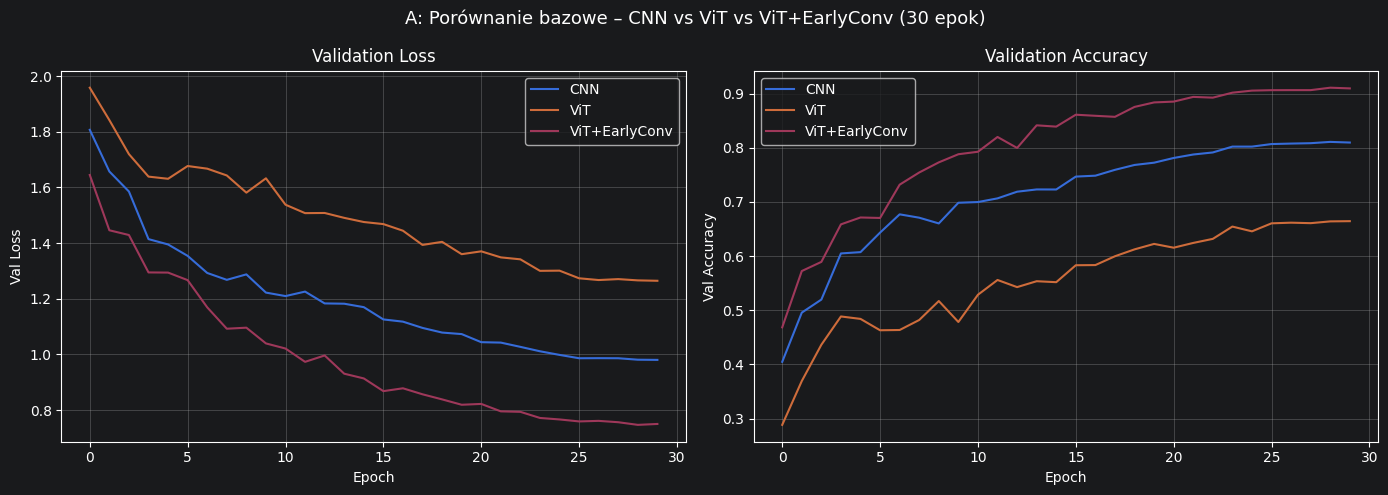


=== Wyniki końcowe (Eksperyment A) ===
  CNN                 : best_val=0.8109  last_val=0.8097
  ViT                 : best_val=0.6645  last_val=0.6645
  ViT+EarlyConv       : best_val=0.9110  last_val=0.9097


In [19]:
print("Liczba parametrów")
for name, m in [("CNN", build_cnn()), ("ViT", build_vit()), ("ViT+EarlyConv", build_vit_ec())]:
    print(f"  {name:20s}: {count_parameters(m):,}")

set_seed(SEED)
histories_main = {}

for name, model, is_cnn in [
    ("CNN",           build_cnn(),    True),
    ("ViT",           build_vit(),    False),
    ("ViT+EarlyConv", build_vit_ec(), False),
]:
    print(f"\nTrening: {name}")
    crit, opt, sched = make_optimizer_and_scheduler(model, is_cnn=is_cnn)
    histories_main[name] = fit(model, opt, sched, crit, train_dl, test_dl, EPOCHS_MAIN)

cnn_model = list(configs := {
    "CNN":           build_cnn(),
    "ViT":           build_vit(),
    "ViT+EarlyConv": build_vit_ec(),
})

_models_A = {}
set_seed(SEED)
for name, model, is_cnn in [
    ("CNN",           build_cnn(),    True),
    ("ViT",           build_vit(),    False),
    ("ViT+EarlyConv", build_vit_ec(), False),
]:
    crit, opt, sched = make_optimizer_and_scheduler(model, is_cnn=is_cnn)
    fit(model, opt, sched, crit, train_dl, test_dl, EPOCHS_MAIN)
    _models_A[name] = model

vit_trained = _models_A["ViT"]
vit_ec_trained = _models_A["ViT+EarlyConv"]

plot_histories(histories_main, "A: Porównanie bazowe – CNN vs ViT vs ViT+EarlyConv (30 epok)")

print("\n=== Wyniki końcowe (Eksperyment A) ===")
for name, hist in histories_main.items():
    print(f"  {name:20s}: best_val={max(hist['val_acc']):.4f}  last_val={hist['val_acc'][-1]:.4f}")

### Wpływ pretrainingu MAE
Porównujemy ViT i ViT+EarlyConv trenowane od zera vs. z pretrainingiem
Masked Autoencoder (mask_ratio=0.75, 8 epok). Czy samo-nadzorowany
pretrain daje mierzalny przyrost na małym CIFAR-10?


MAE pretrain: ViT+MAE
    MAE epoch 1/8 | loss=0.0162
    MAE epoch 2/8 | loss=0.0037
    MAE epoch 3/8 | loss=0.0027
    MAE epoch 4/8 | loss=0.0022
    MAE epoch 5/8 | loss=0.0019
    MAE epoch 6/8 | loss=0.0017
    MAE epoch 7/8 | loss=0.0015
    MAE epoch 8/8 | loss=0.0080
    Fine-tuning: ViT+MAE


Epoch 1/30:   0%|          | 0/782 [00:00<?, ?it/s]

  E01 | train_acc=0.3307 | val_acc=0.3393


Epoch 2/30:   0%|          | 0/782 [00:00<?, ?it/s]

  E02 | train_acc=0.3742 | val_acc=0.3721


...

  E28 | train_acc=0.9135 | val_acc=0.8977


Epoch 29/30:   0%|          | 0/782 [00:00<?, ?it/s]

  E29 | train_acc=0.9147 | val_acc=0.8978


Epoch 30/30:   0%|          | 0/782 [00:00<?, ?it/s]

  E30 | train_acc=0.9150 | val_acc=0.8983


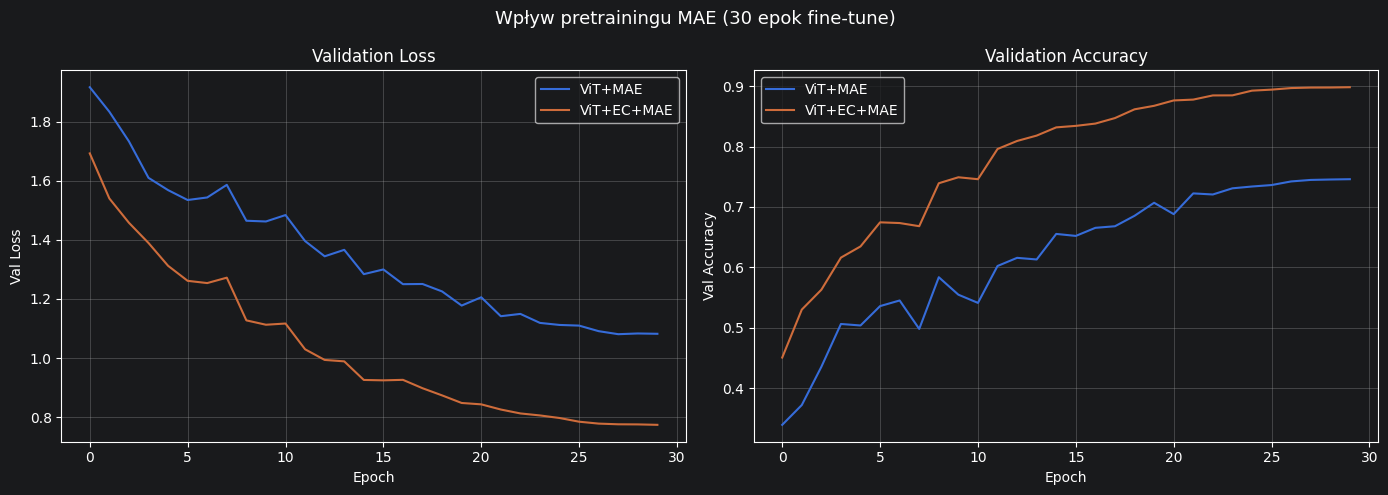


Wyniki końcowe
  ViT+MAE        : best_val=0.7460  last_val=0.7460
  ViT+EC+MAE     : best_val=0.8983  last_val=0.8983


In [19]:
set_seed(SEED)
histories_pretrain = {}

for name, model in [("ViT+MAE", build_vit()), ("ViT+EC+MAE", build_vit_ec())]:
    print(f"\nMAE pretrain: {name}")
    run_pretrain(model)
    print(f"    Fine-tuning: {name}")
    crit, opt, sched = make_optimizer_and_scheduler(model)
    histories_pretrain[name] = fit(model, opt, sched, crit, train_dl, test_dl, EPOCHS_MAIN)

compare_pretrain = {
    "ViT+MAE":      histories_pretrain["ViT+MAE"],
    "ViT+EC+MAE":   histories_pretrain["ViT+EC+MAE"],
}
plot_histories(compare_pretrain, "Wpływ pretrainingu MAE (30 epok fine-tune)")

print("\nWyniki końcowe")
for name, hist in compare_pretrain.items():
    print(f"  {name:15s}: best_val={max(hist['val_acc']):.4f}  last_val={hist['val_acc'][-1]:.4f}")

### Wrażliwość na Learning Rate

Learning rate to najważniejszy hiperparametr ViT – zbyt duże lr powoduje
dywergencję gradientów (NaN), zbyt małe – wolną konwergencję.

Epoch 1/15:   0%|          | 0/782 [00:00<?, ?it/s]

  E01 | train_acc=0.2542 | val_acc=0.2494


Epoch 2/15:   0%|          | 0/782 [00:00<?, ?it/s]

  E02 | train_acc=0.2929 | val_acc=0.2871


Epoch 3/15:   0%|          | 0/782 [00:00<?, ?it/s]

...

  E13 | train_acc=0.8578 | val_acc=0.8543


Epoch 14/15:   0%|          | 0/782 [00:00<?, ?it/s]

  E14 | train_acc=0.8676 | val_acc=0.8651


Epoch 15/15:   0%|          | 0/782 [00:00<?, ?it/s]

  E15 | train_acc=0.8670 | val_acc=0.8617
  ViT+EC lr=2e-03: best=0.8651


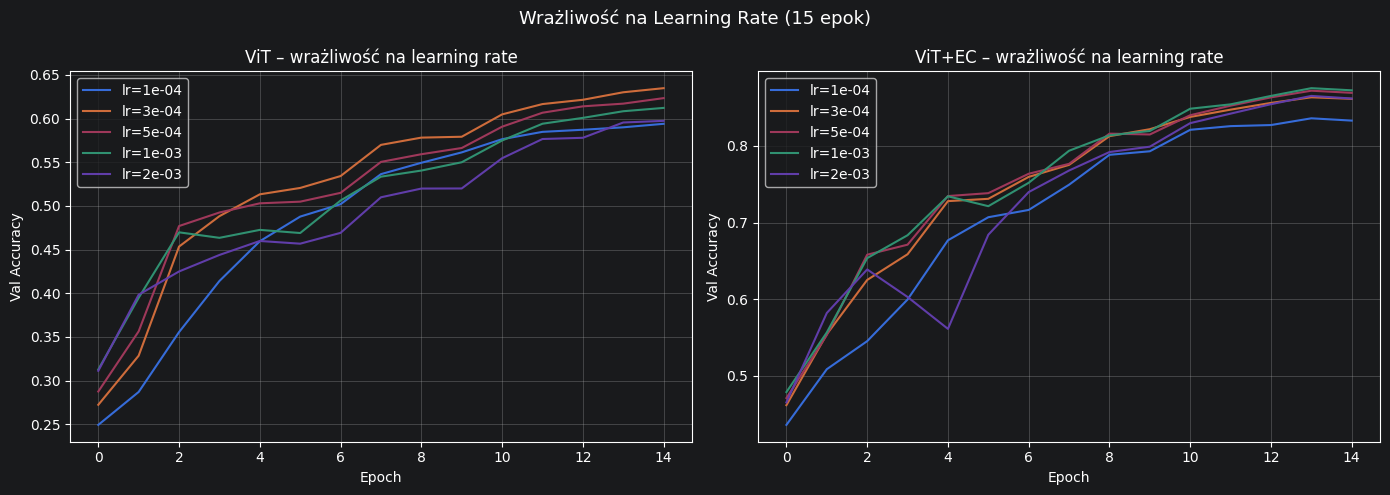


Best val_acc per lr
      lr         ViT      ViT+EC
--------------------------------
   1e-04      0.5940      0.8359
   3e-04      0.6348      0.8633
   5e-04      0.6234      0.8719
   1e-03      0.6122      0.8752
   2e-03      0.5974      0.8651


In [20]:
lr_values = [1e-4, 3e-4, 5e-4, 1e-3, 2e-3]
lr_curves  = {"ViT": {}, "ViT+EC": {}}

for lr in lr_values:
    label = f"{lr:.0e}"
    for arch, builder in [("ViT", build_vit), ("ViT+EC", build_vit_ec)]:
        set_seed(SEED)
        model = builder()
        crit, opt, sched = make_optimizer_and_scheduler(model, max_lr=lr, epochs=EPOCHS_HP)
        hist = fit(model, opt, sched, crit, train_dl, test_dl, EPOCHS_HP)
        lr_curves[arch][label] = hist['val_acc']
        print(f"  {arch} lr={label}: best={max(hist['val_acc']):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, arch in zip(axes, ["ViT", "ViT+EC"]):
    for label, accs in lr_curves[arch].items():
        ax.plot(accs, label=f"lr={label}")
    ax.set_title(f"{arch} – wrażliwość na learning rate")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Val Accuracy")
    ax.legend(); ax.grid(True, alpha=0.4)
plt.suptitle("Wrażliwość na Learning Rate (15 epok)", fontsize=13)
plt.tight_layout(); plt.show()

print("\nBest val_acc per lr")
header = f"{'lr':>8}" + "".join(f"  {a:>10}" for a in ["ViT", "ViT+EC"])
print(header); print("-" * len(header))
for lr in lr_values:
    label = f"{lr:.0e}"
    row = f"{label:>8}"
    for arch in ["ViT", "ViT+EC"]:
        row += f"  {max(lr_curves[arch][label]):>10.4f}"
    print(row)

### Wrażliwość na Drop Path Rate (Stochastic Depth)

DropPath wyłącza całe ścieżki obliczeniowe podczas treningu, co wymusza
budowanie alternatywnych reprezentacji. Zbyt mały współczynnik = overfitting, zbyt duży = niestabilny trening. Testujemy zakres 0.0–0.4.

Epoch 1/15:   0%|          | 0/782 [00:00<?, ?it/s]

  E01 | train_acc=0.3098 | val_acc=0.3148


Epoch 2/15:   0%|          | 0/782 [00:00<?, ?it/s]

  E02 | train_acc=0.3974 | val_acc=0.3864


Epoch 3/15:   0%|          | 0/782 [00:00<?, ?it/s]

...

  E13 | train_acc=0.8702 | val_acc=0.8647


Epoch 14/15:   0%|          | 0/782 [00:00<?, ?it/s]

  E14 | train_acc=0.8755 | val_acc=0.8724


Epoch 15/15:   0%|          | 0/782 [00:00<?, ?it/s]

  E15 | train_acc=0.8785 | val_acc=0.8726
  ViT+EC dpr=0.4: best=0.8726


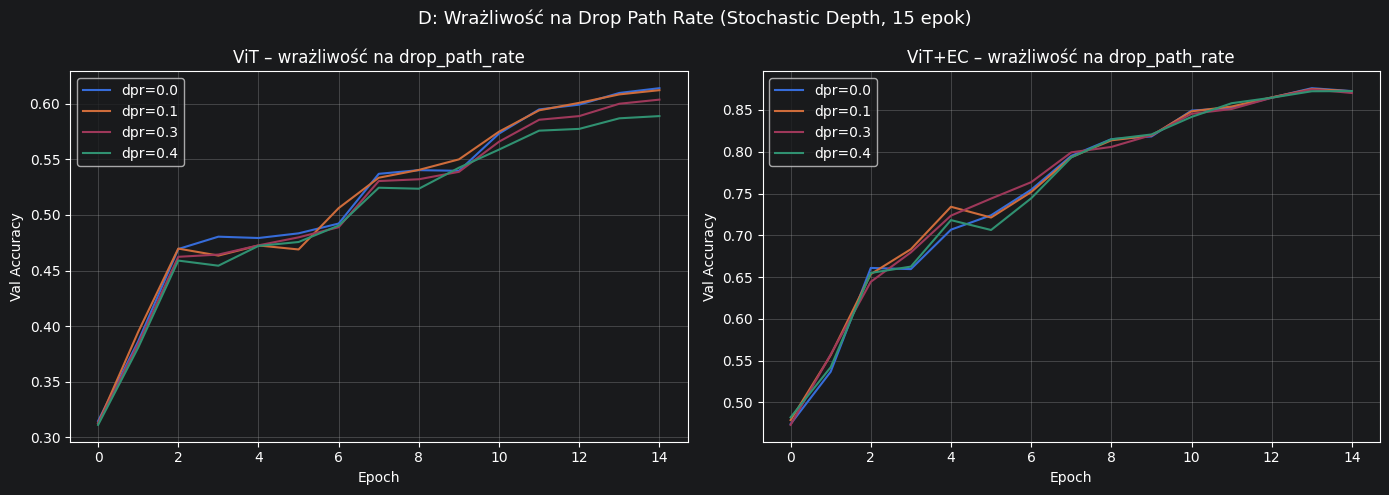


Best val_acc per drop_path_rate
   dpr         ViT      ViT+EC
------------------------------
   0.0      0.6140      0.8761
   0.1      0.6122      0.8752
   0.3      0.6037      0.8747
   0.4      0.5889      0.8726


In [19]:
dpr_values = [0.0, 0.1, 0.3, 0.4]
dpr_curves  = {"ViT": {}, "ViT+EC": {}}

for dpr in dpr_values:
    label = str(dpr)
    for arch, builder in [("ViT", build_vit), ("ViT+EC", build_vit_ec)]:
        set_seed(SEED)
        model = builder(drop_path_rate=dpr)
        crit, opt, sched = make_optimizer_and_scheduler(model, epochs=EPOCHS_HP)
        hist = fit(model, opt, sched, crit, train_dl, test_dl, EPOCHS_HP)
        dpr_curves[arch][label] = hist['val_acc']
        print(f"  {arch} dpr={label}: best={max(hist['val_acc']):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, arch in zip(axes, ["ViT", "ViT+EC"]):
    for label, accs in dpr_curves[arch].items():
        ax.plot(accs, label=f"dpr={label}")
    ax.set_title(f"{arch} – wrażliwość na drop_path_rate")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Val Accuracy")
    ax.legend(); ax.grid(True, alpha=0.4)
plt.suptitle("D: Wrażliwość na Drop Path Rate (Stochastic Depth, 15 epok)", fontsize=13)
plt.tight_layout(); plt.show()

print("\nBest val_acc per drop_path_rate")
header = f"{'dpr':>6}" + "".join(f"  {a:>10}" for a in ["ViT", "ViT+EC"])
print(header); print("-" * len(header))
for dpr in dpr_values:
    label = str(dpr)
    row = f"{label:>6}"
    for arch in ["ViT", "ViT+EC"]:
        row += f"  {max(dpr_curves[arch][label]):>10.4f}"
    print(row)

### Ablacje

Sprawdzamy, jak bardzo każdy składnik systemu przyczynia się do wyniku końcowego. Punktem odniesienia jest ViT+EarlyConv z pełną konfiguracją.
Każda ablacja usuwa jeden element i mierzy spadek dokładności.


Ablacja: ViT+EC pełny


Epoch 1/15:   0%|          | 0/782 [00:00<?, ?it/s]

  E01 | train_acc=0.4677 | val_acc=0.4789


Epoch 2/15:   0%|          | 0/782 [00:00<?, ?it/s]

  E02 | train_acc=0.5530 | val_acc=0.5566


...

  E13 | train_acc=0.8674 | val_acc=0.8645


Epoch 14/15:   0%|          | 0/782 [00:00<?, ?it/s]

  E14 | train_acc=0.8760 | val_acc=0.8741


Epoch 15/15:   0%|          | 0/782 [00:00<?, ?it/s]

  E15 | train_acc=0.8752 | val_acc=0.8711


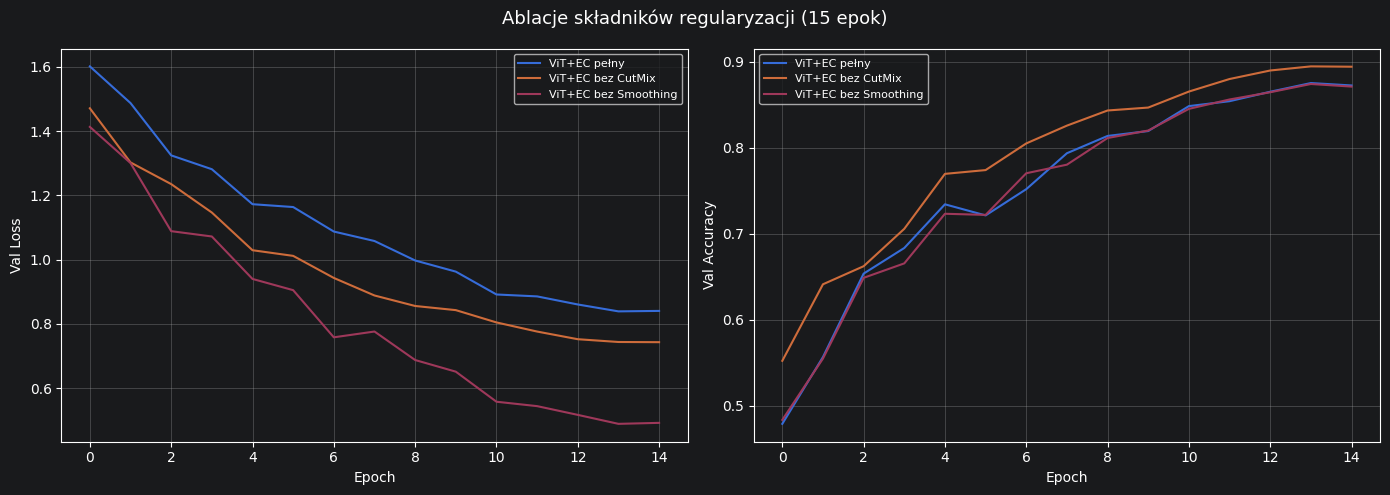


Wyniki ablacji – max val_acc


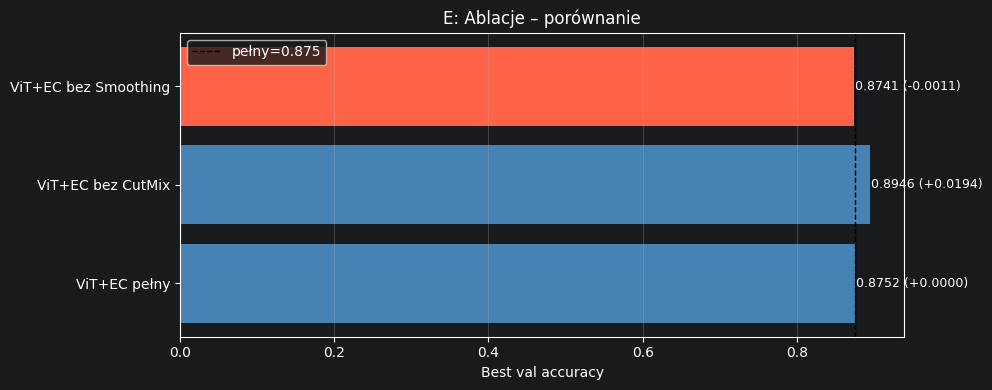

  ViT+EC pełny                  : 0.8752  (Δ=+0.0000)
  ViT+EC bez CutMix             : 0.8946  (Δ=+0.0194)
  ViT+EC bez Smoothing          : 0.8741  (Δ=-0.0011)


In [19]:
ablation_configs = [
    ("ViT+EC pełny",        build_vit_ec, 0.1,       True,       True),
    ("ViT+EC bez CutMix",   build_vit_ec, 0.1,       False,      True),
    ("ViT+EC bez Smoothing",build_vit_ec, 0.1,       True,       False),
]

ablation_results = {}
for (name, builder, dpr, cutmix, smooth) in ablation_configs:
    set_seed(SEED)
    model = builder(drop_path_rate=dpr)
    crit  = nn.CrossEntropyLoss(label_smoothing=0.1 if smooth else 0.0)
    opt   = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.05)
    sched = optim.lr_scheduler.OneCycleLR(
        opt, max_lr=1e-3, steps_per_epoch=len(train_dl), epochs=EPOCHS_HP)
    print(f"\nAblacja: {name}")
    ablation_results[name] = fit(model, opt, sched, crit, train_dl, test_dl,
                                 EPOCHS_HP, use_cutmix=cutmix)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, hist in ablation_results.items():
    axes[0].plot(hist['val_loss'], label=name)
    axes[1].plot(hist['val_acc'],  label=name)
for ax, lbl in zip(axes, ['Val Loss', 'Val Accuracy']):
    ax.set_xlabel('Epoch'); ax.set_ylabel(lbl)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
plt.suptitle("Ablacje składników regularyzacji (15 epok)", fontsize=13)
plt.tight_layout(); plt.show()

full_best = max(ablation_results["ViT+EC pełny"]['val_acc'])
print("\nWyniki ablacji – max val_acc")
names_abl = list(ablation_results.keys())
bests_abl = [max(h['val_acc']) for h in ablation_results.values()]
deltas    = [b - full_best for b in bests_abl]

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['steelblue' if d >= 0 else 'tomato' for d in deltas]
bars   = ax.barh(names_abl, bests_abl, color=colors)
ax.axvline(full_best, color='black', linestyle='--', linewidth=1, label=f'pełny={full_best:.3f}')
for bar, v, d in zip(bars, bests_abl, deltas):
    sign = '+' if d >= 0 else ''
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{v:.4f} ({sign}{d:.4f})", va='center', fontsize=9)
ax.set_xlabel("Best val accuracy"); ax.set_title("E: Ablacje – porównanie")
ax.legend(); ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout(); plt.show()

for name, best, delta in zip(names_abl, bests_abl, deltas):
    sign = '+' if delta >= 0 else ''
    print(f"  {name:30s}: {best:.4f}  (Δ={sign}{delta:.4f})")